In [1]:
from starccato_flow.training.trainer_flow_matching_multi import FlowMatchingTrainerMulti
from starccato_flow.supernovae.supernovae import Supernovae
from starccato_flow.utils.defaults import TEN_KPC
import numpy as np

MPS device found


/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
font_family = "sans-serif"
font_name = "avenir"

In [3]:
trainer_sky = FlowMatchingTrainerMulti(num_epochs=256, toy=False, parameters=["ra", "dec", "d", "psi"])
trainer_sky.load_model_instance(model_path="../outdir/flow_sky_weights_test.pt")


=== Parameter Extraction Setup ===
Requested parameters: ['ra', 'dec', 'd', 'psi']
Intrinsic params: []
Sky params: ['ra', 'dec', 'd', 'psi']
Extract indices (sequential from hThetaMulti): [0, 1, 2, 3]
Final flow parameter dimension: 4

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv

sTheta Dataset - Parameter Bounds (0 parameters)


=== Data Split ===
Total signals: 1684
Training signals: 1516
Validation signals: 168
First 5 training indices: [ 360  336   81  684 1374]
First 5 validation indices: [722 519 222  32 111]

sTheta Dataset - Parameter Bounds (0 parameters)


sTheta Dataset - Parameter Bounds (0 parameters)


Verifying data alignment:
Number of signals: 1516
Number of parameter sets: 1516
Parameter names: []
First few parameter values:
[]

Verifying data alignment:
Number of signals: 168
Number of parameter sets: 168
Parameter names: []
First few parameter values:
[]

=== D

Loaded 256 training loss entries from /Users/tarineccleston/Desktop/starccato/starccato-flow/outdir/flow_matching/losses.csv


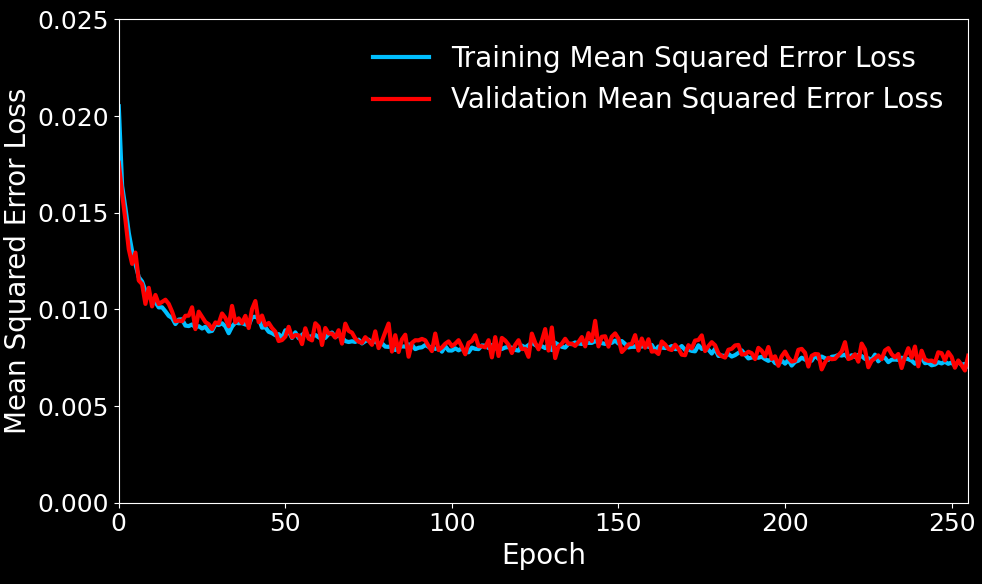

In [4]:
trainer_sky.load_losses()
trainer_sky.display_results(fname="../../poster-presentation/flow_sky_results.svg", font_family=font_family, font_name=font_name, background="black")


hThetaMulti Dataset - Parameter Bounds (4 parameters)
INTRINSIC PARAMETERS:

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [   -3.141593,     3.141593]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    10.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 1
Multi-channel shape: (1, 3, 256)
Parameter dimension: 4
Parameters include theta + sky: [ra, dec, d, polar_angle]


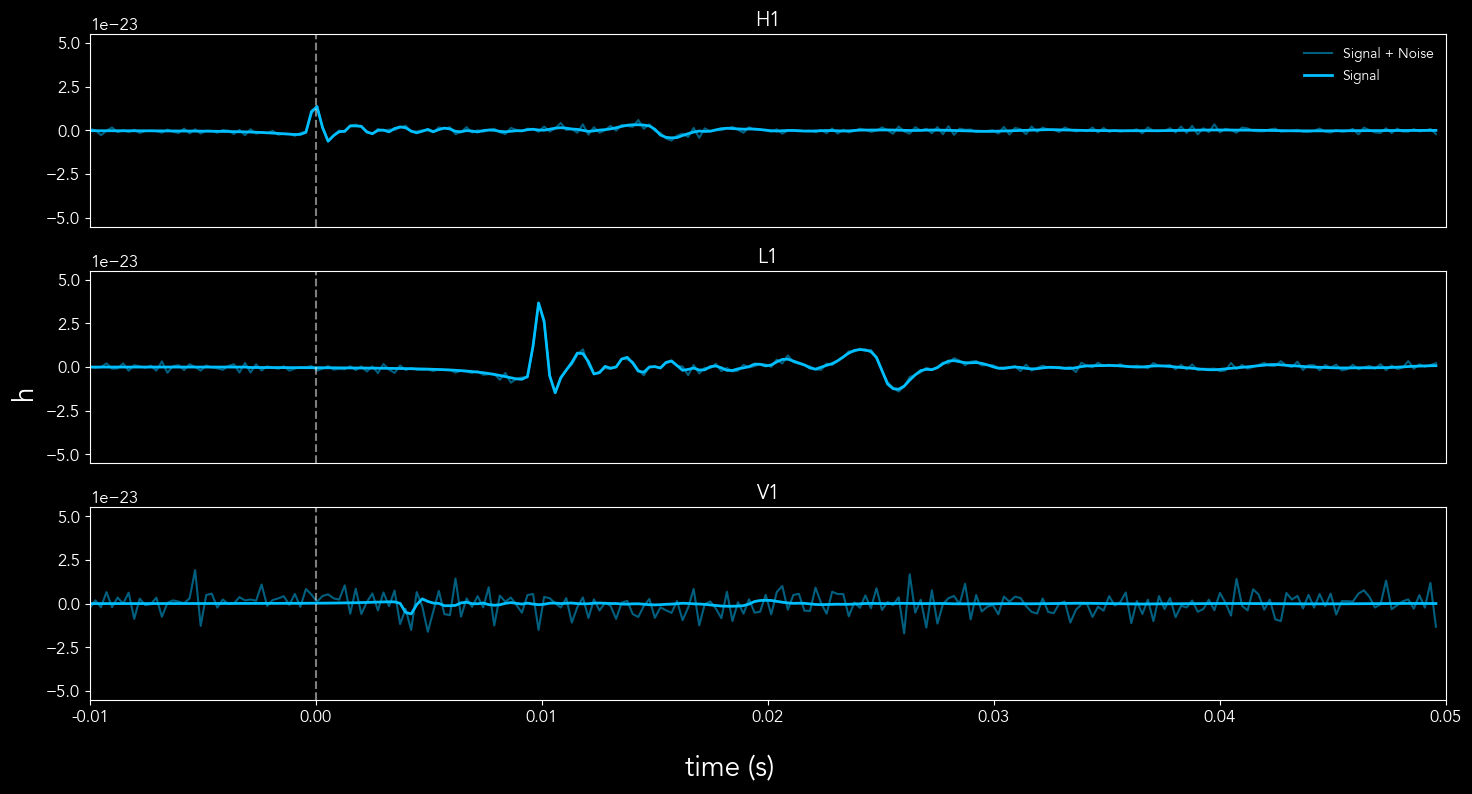


=== RAW FLOW OUTPUT (Normalized Space [-1, 1]) ===
Shape: (3000, 4)
  ra        : min=-0.6255, max=0.7331, mean=0.2969, std=0.1388
  dec       : min=-0.6511, max=0.6347, mean=0.1898, std=0.1600
  d         : min=-1.0710, max=1.1274, mean=0.2638, std=0.3130
  psi       : min=-1.3387, max=1.2186, mean=0.0880, std=0.2901

=== DENORMALIZED OUTPUT (Physical Units) ===
  ra        : min=-1.9650, max=2.3031
             bounds: [-3.1416, 3.1416]
  dec       : min=-1.0228, max=0.9969
             bounds: [-1.5708, 1.5708]
  d         : min=-0.3548, max=10.6368
             bounds: [0.0000, 10.0000]
  psi       : min=-0.5321, max=3.4850
             bounds: [0.0000, 3.1416]
Posterior sampling and denormalisation took 0.26s

Plot axis ranges (from plotting_defaults PARAMETER_RANGES):
  ra                  : (-3.141592653589793, 3.141592653589793)
  dec                 : (-1.5707963267948966, 1.5707963267948966)
  d                   : (0, 10)
  psi                 : (0, 3.141592653589793)

Debu

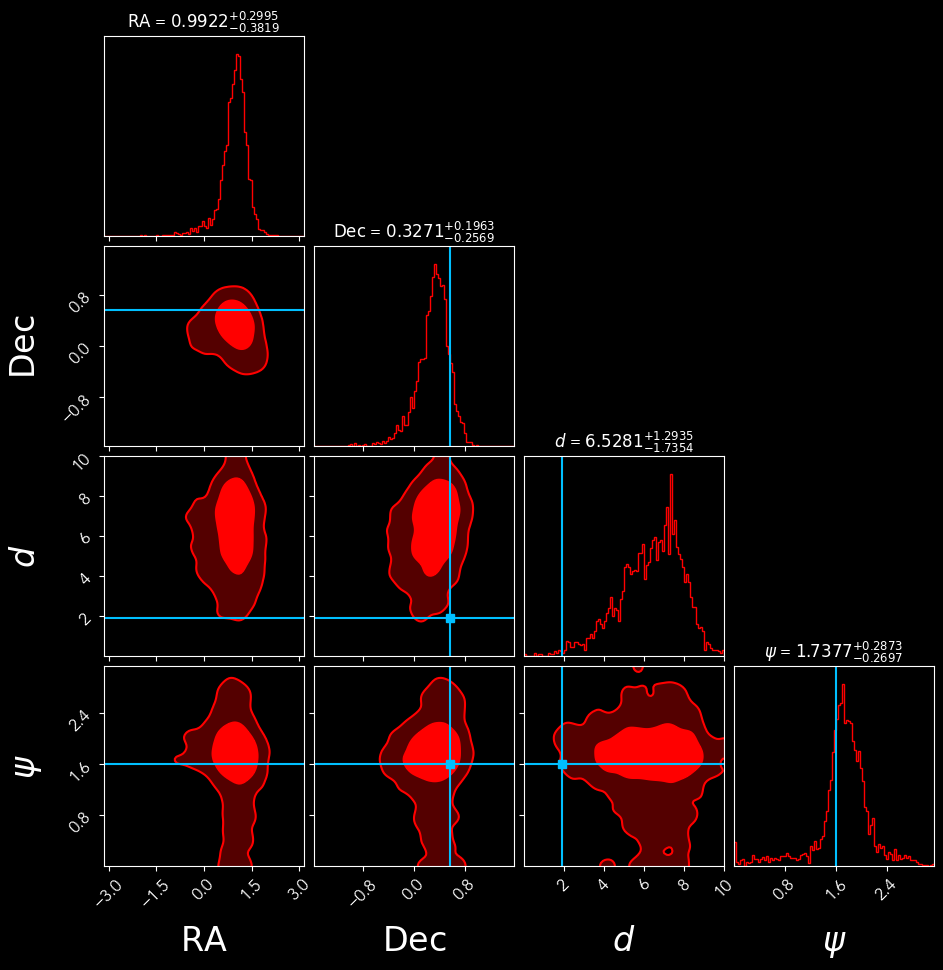


True parameters to plot:
  ra: 5.360424
    RA in degrees: 307.13°
  dec: 0.572279
    Dec in degrees: 32.79°
  d: 1.902753
  psi: 1.607935

Sky Localisation Plot Debug:
  ra_idx: 0, dec_idx: 1
  true_param_denorm shape: (4,)
  parameters_to_estimate: ['ra', 'dec', 'd', 'psi']
  true_ra: 5.360424 rad = 307.13°
  true_dec: 0.572279 rad = 32.79°
  SVG output: Using 800 samples (downsampled from 3000)


/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/plotting/sky.py:552: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax_l.contourf(xcenters, ycenters, h_n_plot, levels=smooth_levels, colors=smooth_colors, antialiased=True, rasterized=False)
/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/plotting/sky.py:583: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax_r.contourf(xcenters, ycenters, h_s_plot, levels=smooth_levels, colors=smooth_colors, antialiased=True, rasterized=False)



Galactic Center Direction:
  RA:  4.649646 rad = 266.41°
  Dec: -0.505032 rad = -28.94°



/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/plotting/sky.py:917: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax_l.contourf(
/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/plotting/sky.py:926: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax_r.contourf(


Optimized SVG: ../../poster-presentation/flow_sky_posterior_sky.svg (4662.8 KB)


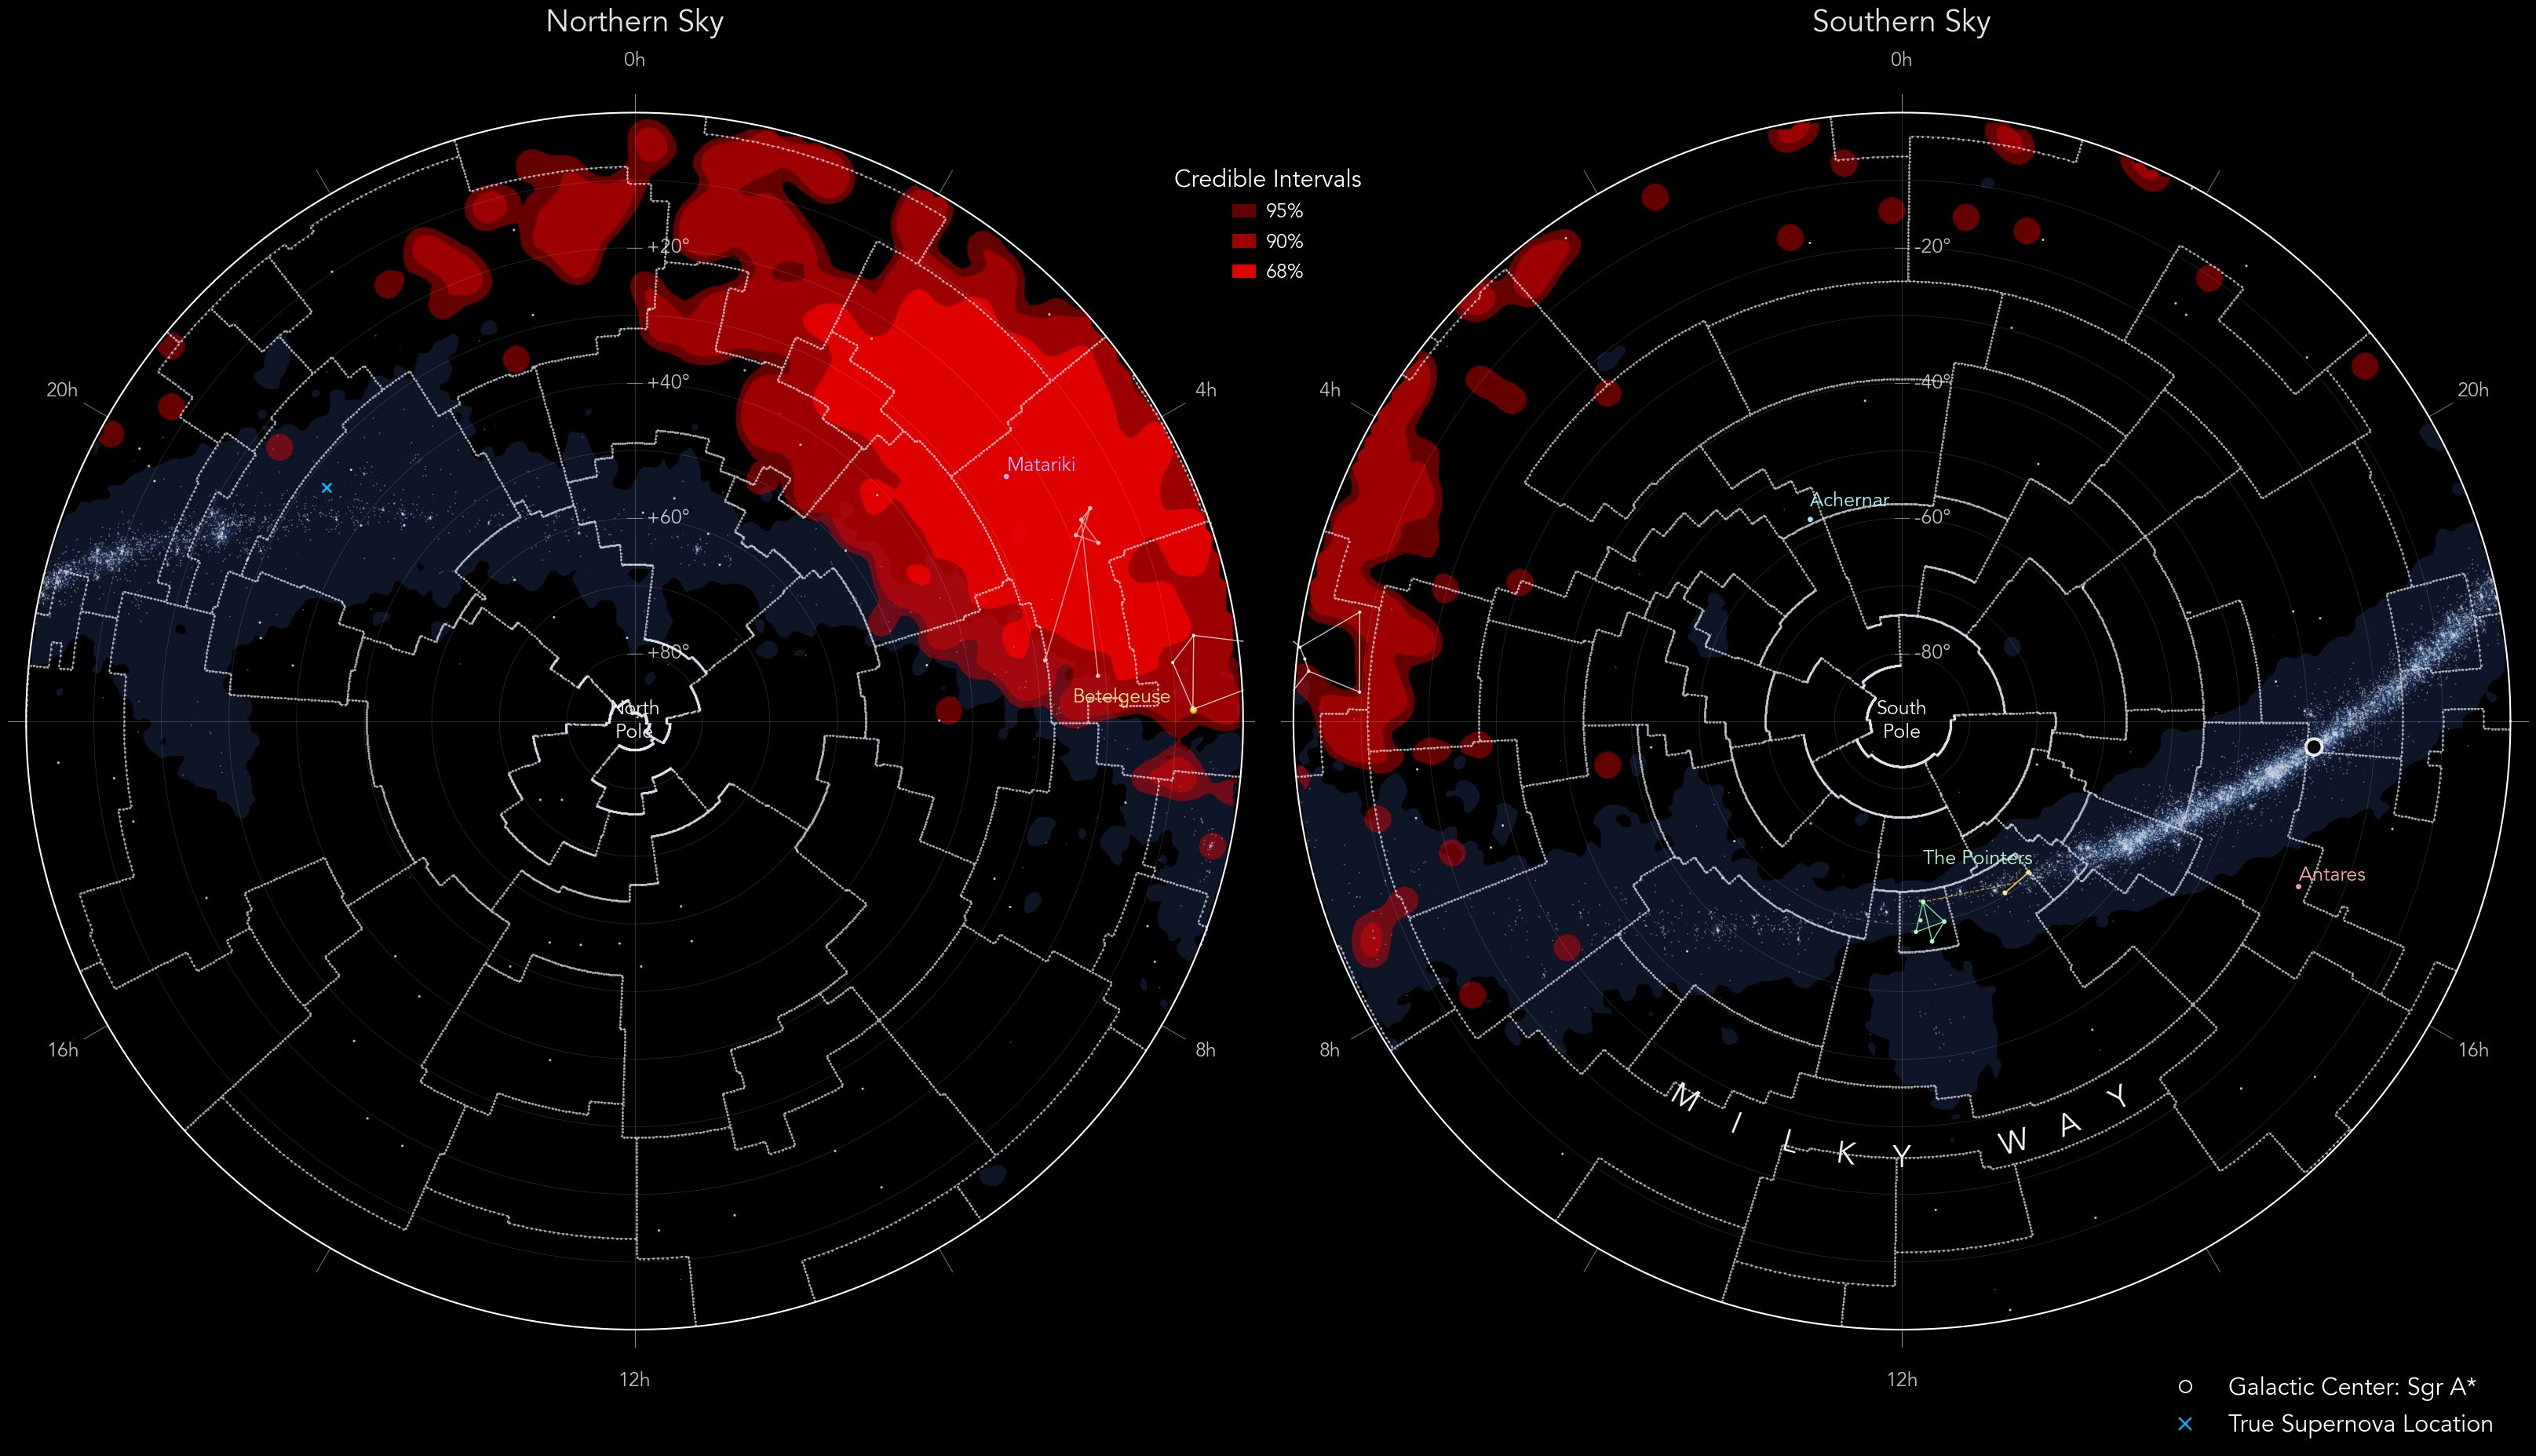

  SVG compression: 4663 KB → 675 KB (14%)


In [5]:
trainer_sky.run_parameter_estimation(signal_idx=1, d=2.0, fname_signal="../../poster-presentation/flow_sky_signal.svg", fname_posterior="../../poster-presentation/flow_sky_posterior.svg", fname_posterior_sky="../../poster-presentation/flow_sky_posterior_sky.svg", fname_posterior_galactic="../../poster-presentation/flow_sky_posterior_galactic.png", background="black", font_family=font_family, font_name=font_name, export_on=False, transparent=True)

In [6]:
# trainer_sky.plot_pp_coverage_validation(
#     fname="../../poster-presentation/flow_sky_pp_coverage.svg",
#     background="black",
#     font_family=font_family,
#     font_name=font_name,
#     transparent=True
# )